# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle. 

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

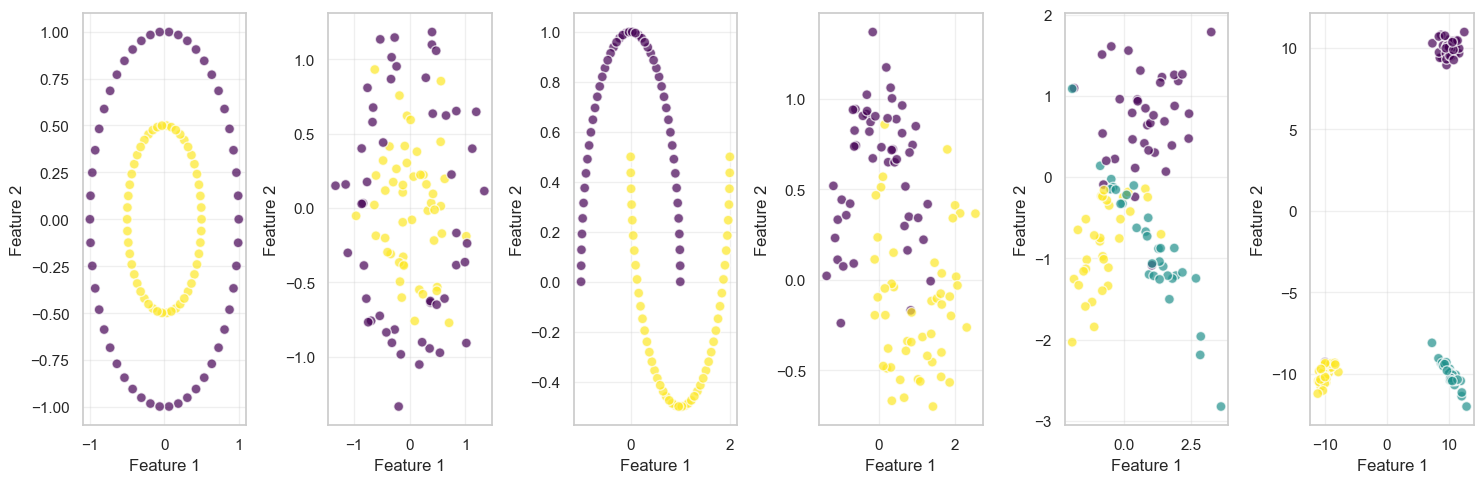

In [25]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    ("Круги", make_circles(noise=0.2, factor=0.5, random_state=42)),
    ("Полумесяцы", make_moons(noise=0.2, random_state=42)),
    ("Классы", make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, ))
]

datasets_my = [
    ("Circles1", make_circles(noise=0, factor=0.5, random_state=42)),
    ("Circles2", make_circles(noise=0.2, factor=0.5, random_state=42)),
    ("Moons1", make_moons(noise=0, random_state=42)),
    ("Moons2", make_moons(noise=0.2, random_state=42)),
    ("Classification1", make_classification(
        n_classes=3,
        n_clusters_per_class=1,
        n_features=2,
        class_sep=0.8,
        random_state=3,
        n_redundant=0
    )),
    ("Classification2", make_classification(
        n_classes=3,
        n_clusters_per_class=1,
        n_features=2,
        class_sep=10,
        random_state=3,
        n_redundant=0
    ))
]

plt.figure(figsize=(15, 5))

for i, (name, (X, y)) in enumerate(datasets_my, 1):
    plt.subplot(1, 6, i)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7, edgecolors='w', s=50)

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

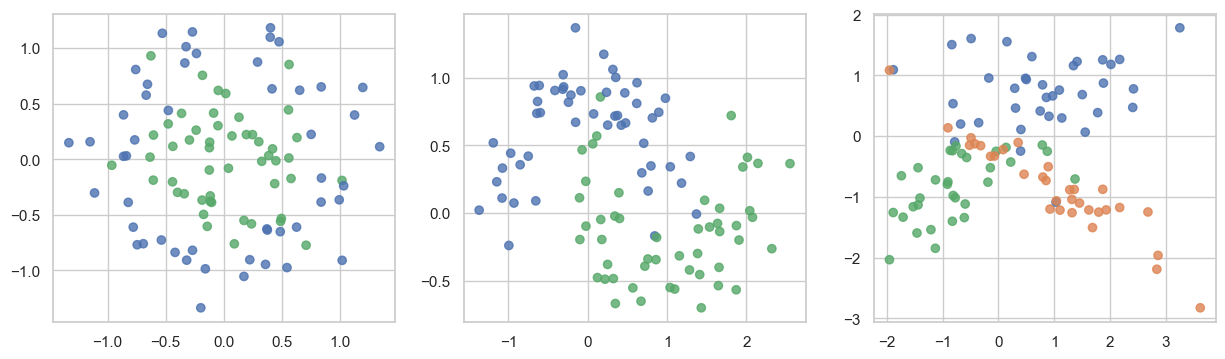

In [27]:
plt.figure(figsize=(15, 4))
for i, (name, (x, y)) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [28]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

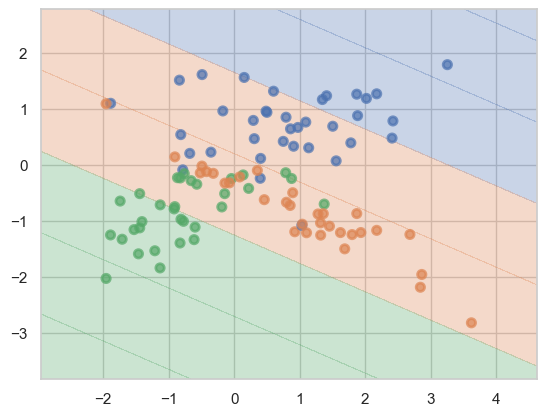

In [29]:
# Пример:
from sklearn.linear_model import LinearRegression
(name, (X, y)) = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

In [30]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

name: {} Круги
train_acc: {} 1.0
Обучающая accuracy: 1.0000
Тестовая accuracy: 0.7333
Разница: 0.2667 → Сильное переобучение

name: {} Полумесяцы
train_acc: {} 1.0
Обучающая accuracy: 1.0000
Тестовая accuracy: 0.8667
Разница: 0.1333 → Умеренное

name: {} Классы
train_acc: {} 1.0
Обучающая accuracy: 1.0000
Тестовая accuracy: 0.8333
Разница: 0.1667 → Сильное переобучение



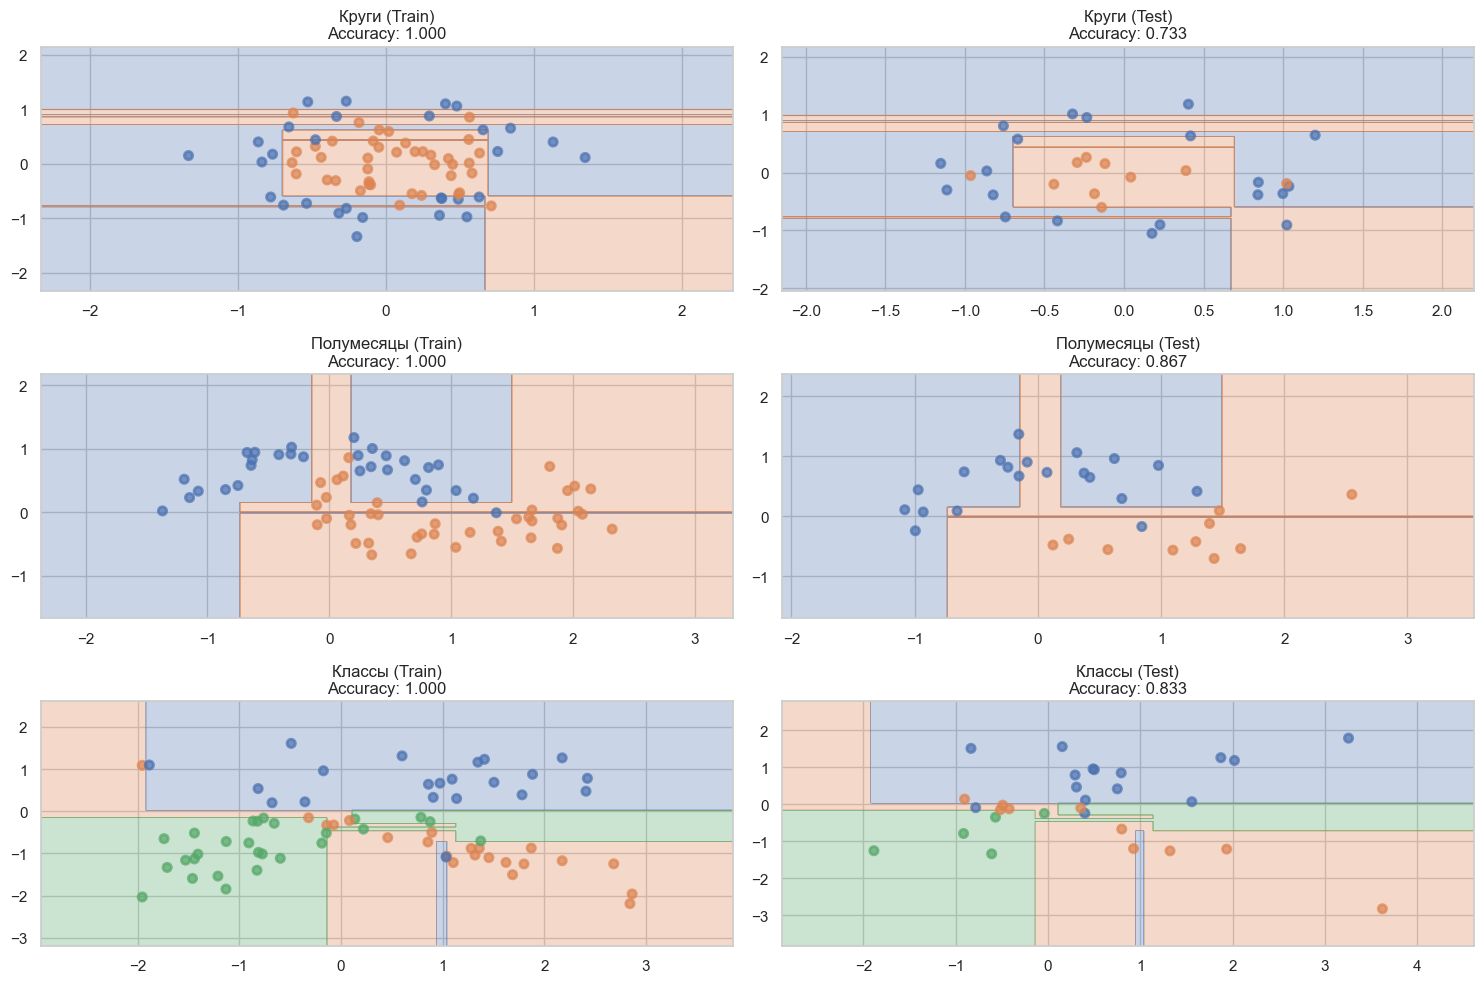

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

plt.figure(figsize=(15, 10))
for i, (name, (X, y)) in enumerate(datasets):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc = accuracy_score(y_test, tree.predict(X_test))
    gap = train_acc - test_acc

    print("name: {}", name)
    print("train_acc: {}", train_acc)
    print(f"Обучающая accuracy: {train_acc:.4f}")
    print(f"Тестовая accuracy: {test_acc:.4f}")
    print(f"Разница: {gap:.4f} → {'Сильное переобучение' if gap > 0.15 else 'Умеренное' if gap > 0.05 else 'Минимальное'}\n")

    plt.subplot(3, 2, 2*i+1)
    plot_surface(tree, X_train, y_train)
    plt.title(f"{name} (Train)\nAccuracy: {train_acc:.3f}")

    plt.subplot(3, 2, 2*i+2)
    plot_surface(tree, X_test, y_test)
    plt.title(f"{name} (Test)\nAccuracy: {test_acc:.3f}")

plt.tight_layout()
plt.show()



__Ответ:__

Наблюдается сильное переобучение: accuracy на обучении достигает 1.0, тогда как на тесте значительно ниже. Это происходит потому, что дерево без ограничений строит излишне сложные границы, 'подстраиваясь' под шум в данных. Однако обобщающую способность можно улучшить, путем регуоирования гиперпараметров.

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

In [32]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ


ДАТАСЕТ: Круги


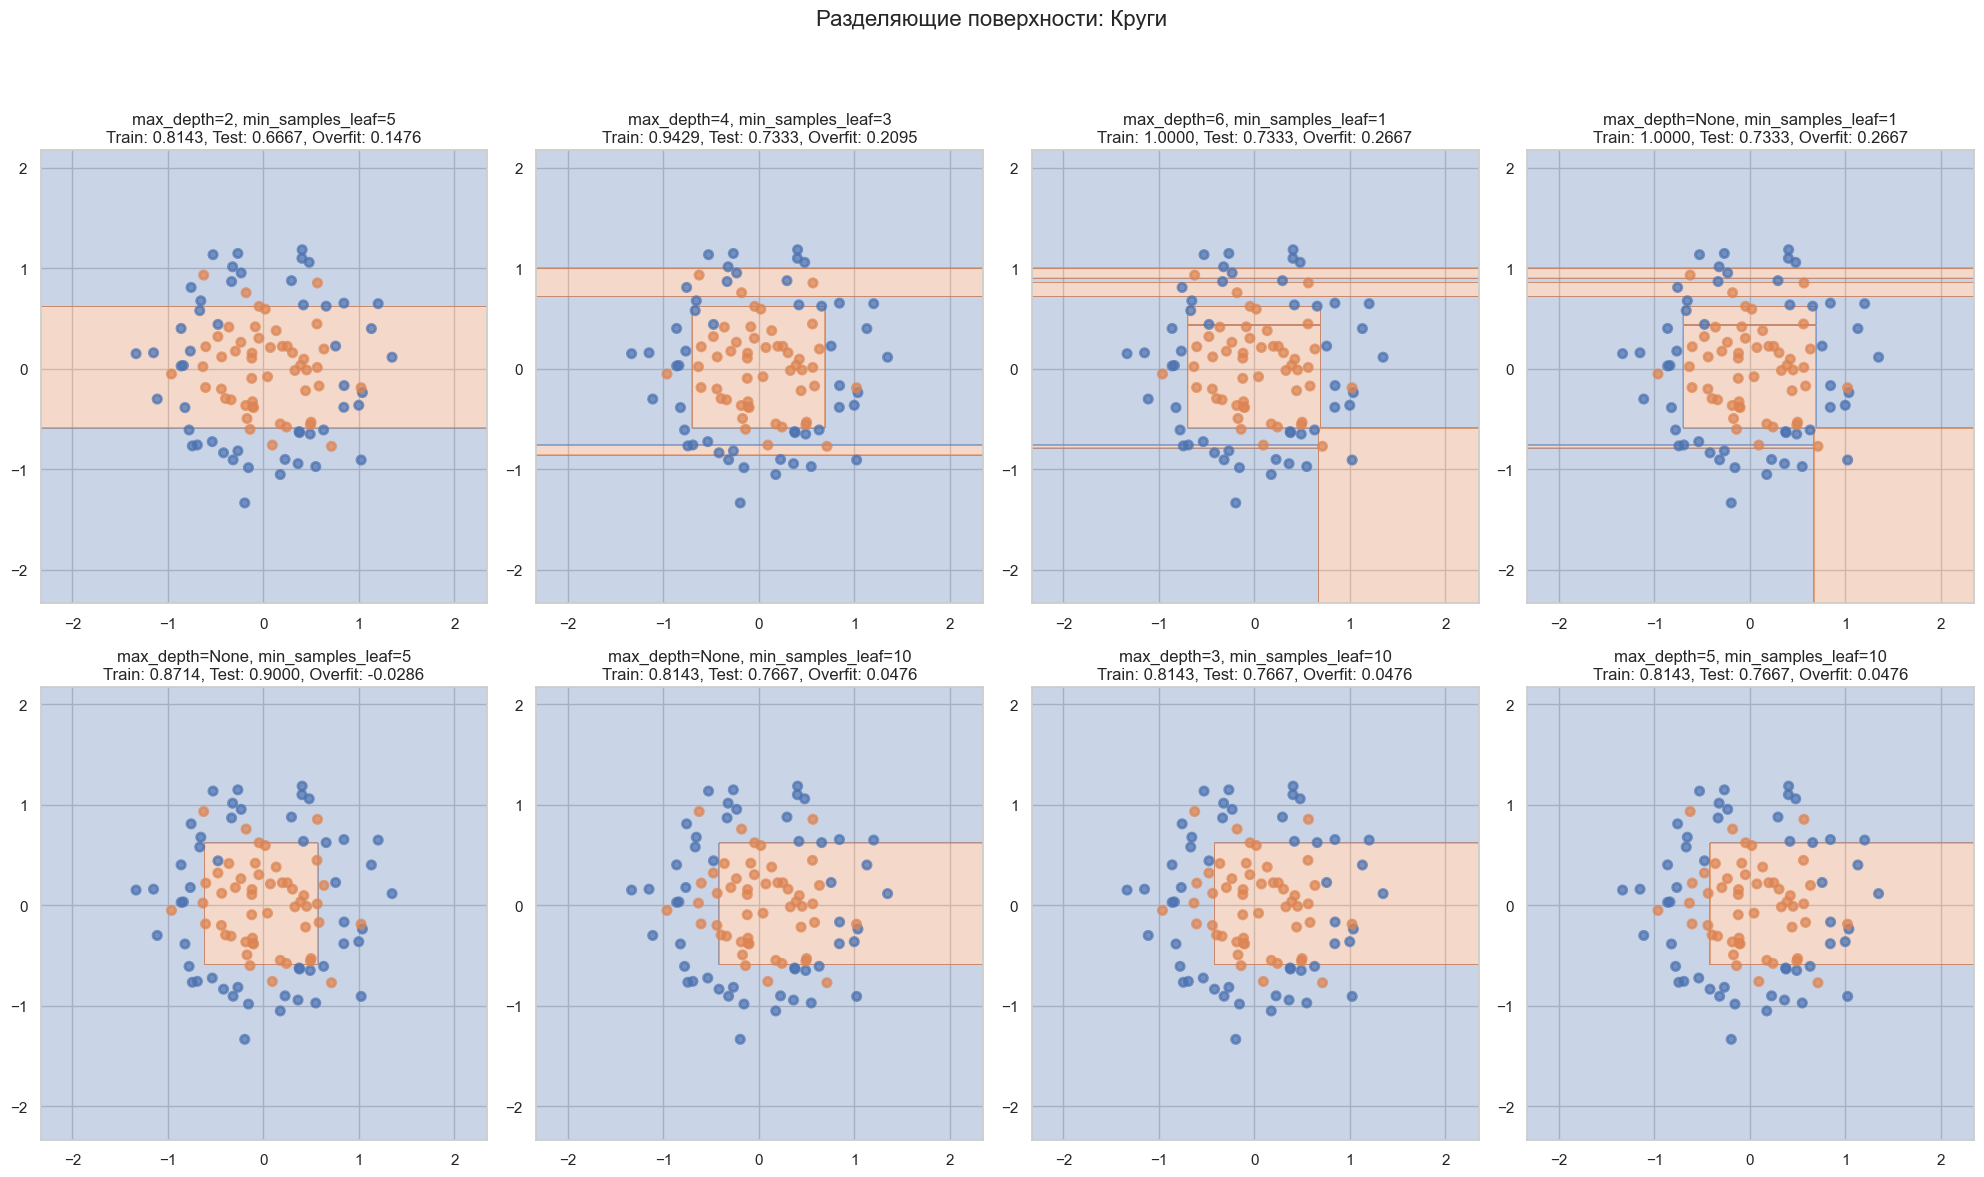


Результаты для разных параметров:
max_depth=   2, min_samples_leaf= 5 | Train: 0.8143, Test: 0.6667, Overfit: 0.1476
max_depth=   4, min_samples_leaf= 3 | Train: 0.9429, Test: 0.7333, Overfit: 0.2095
max_depth=   6, min_samples_leaf= 1 | Train: 1.0000, Test: 0.7333, Overfit: 0.2667
max_depth=None, min_samples_leaf= 1 | Train: 1.0000, Test: 0.7333, Overfit: 0.2667
max_depth=None, min_samples_leaf= 5 | Train: 0.8714, Test: 0.9000, Overfit: -0.0286
max_depth=None, min_samples_leaf=10 | Train: 0.8143, Test: 0.7667, Overfit: 0.0476
max_depth=   3, min_samples_leaf=10 | Train: 0.8143, Test: 0.7667, Overfit: 0.0476
max_depth=   5, min_samples_leaf=10 | Train: 0.8143, Test: 0.7667, Overfit: 0.0476

ДАТАСЕТ: Полумесяцы


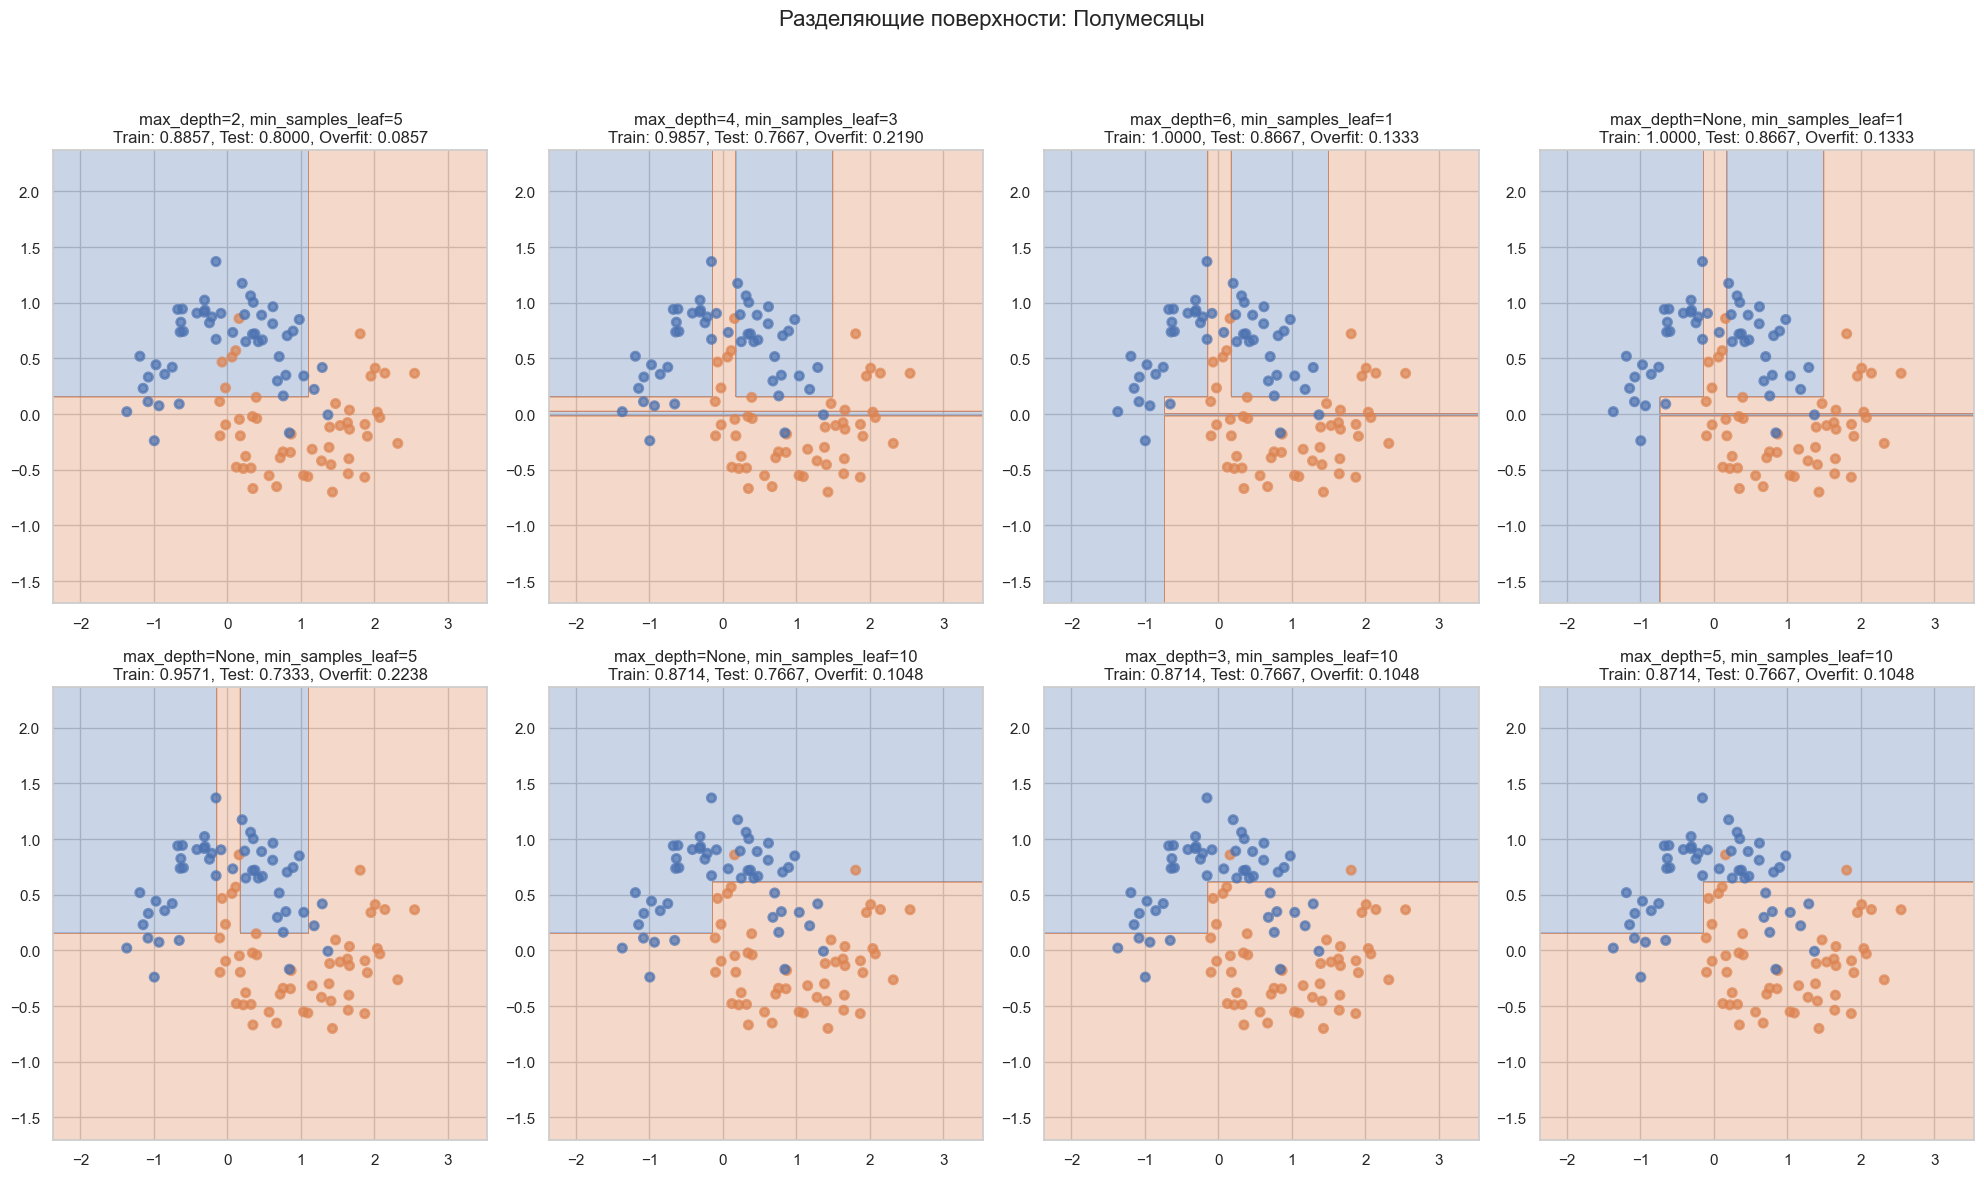


Результаты для разных параметров:
max_depth=   2, min_samples_leaf= 5 | Train: 0.8857, Test: 0.8000, Overfit: 0.0857
max_depth=   4, min_samples_leaf= 3 | Train: 0.9857, Test: 0.7667, Overfit: 0.2190
max_depth=   6, min_samples_leaf= 1 | Train: 1.0000, Test: 0.8667, Overfit: 0.1333
max_depth=None, min_samples_leaf= 1 | Train: 1.0000, Test: 0.8667, Overfit: 0.1333
max_depth=None, min_samples_leaf= 5 | Train: 0.9571, Test: 0.7333, Overfit: 0.2238
max_depth=None, min_samples_leaf=10 | Train: 0.8714, Test: 0.7667, Overfit: 0.1048
max_depth=   3, min_samples_leaf=10 | Train: 0.8714, Test: 0.7667, Overfit: 0.1048
max_depth=   5, min_samples_leaf=10 | Train: 0.8714, Test: 0.7667, Overfit: 0.1048

ДАТАСЕТ: Классы


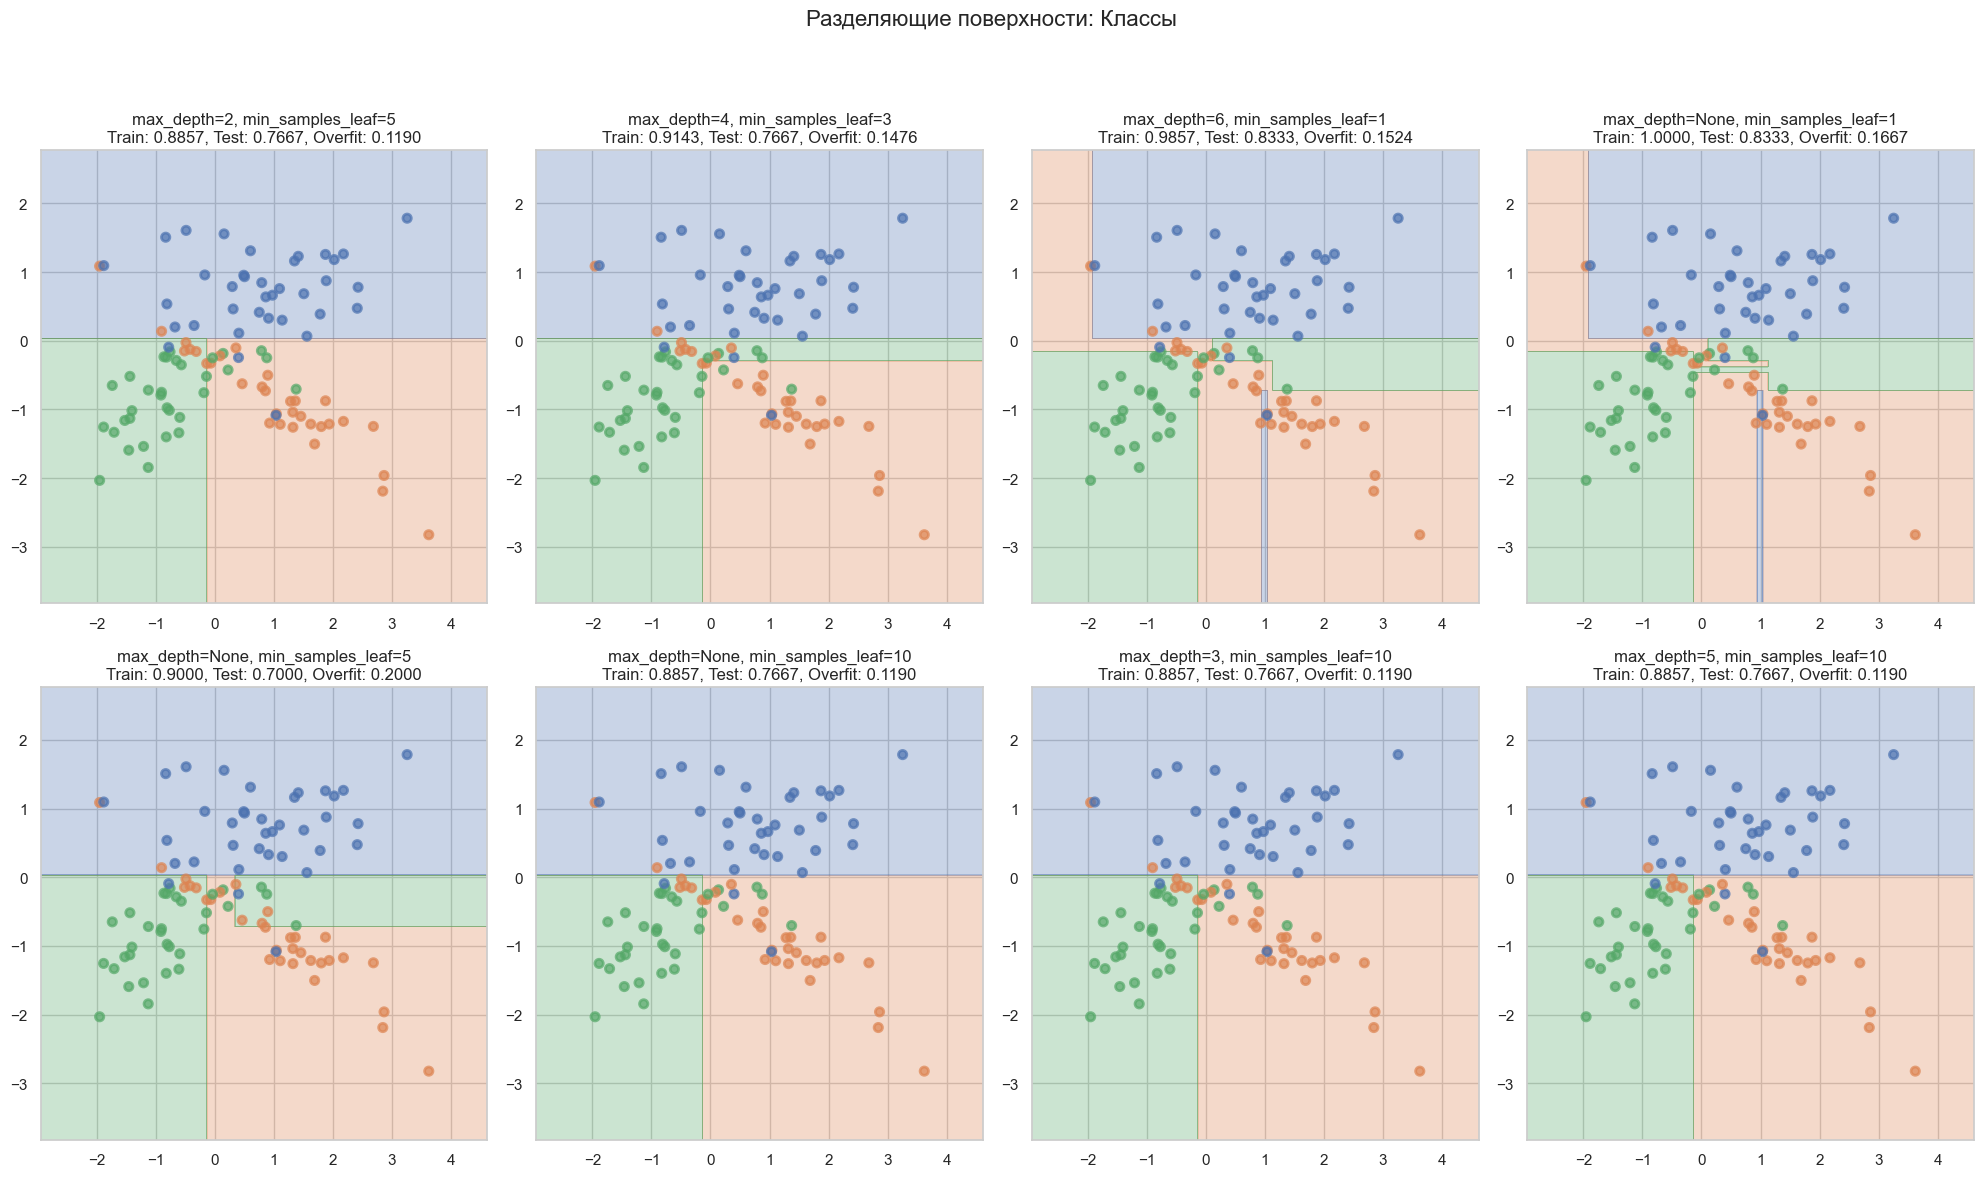


Результаты для разных параметров:
max_depth=   2, min_samples_leaf= 5 | Train: 0.8857, Test: 0.7667, Overfit: 0.1190
max_depth=   4, min_samples_leaf= 3 | Train: 0.9143, Test: 0.7667, Overfit: 0.1476
max_depth=   6, min_samples_leaf= 1 | Train: 0.9857, Test: 0.8333, Overfit: 0.1524
max_depth=None, min_samples_leaf= 1 | Train: 1.0000, Test: 0.8333, Overfit: 0.1667
max_depth=None, min_samples_leaf= 5 | Train: 0.9000, Test: 0.7000, Overfit: 0.2000
max_depth=None, min_samples_leaf=10 | Train: 0.8857, Test: 0.7667, Overfit: 0.1190
max_depth=   3, min_samples_leaf=10 | Train: 0.8857, Test: 0.7667, Overfit: 0.1190
max_depth=   5, min_samples_leaf=10 | Train: 0.8857, Test: 0.7667, Overfit: 0.1190


In [33]:

param_grid = [
    {"max_depth": 2, "min_samples_leaf": 5},
    {"max_depth": 4, "min_samples_leaf": 3},
    {"max_depth": 6, "min_samples_leaf": 1},
    {"max_depth": None, "min_samples_leaf": 1},
    {"max_depth": None, "min_samples_leaf": 5},
    {"max_depth": None, "min_samples_leaf": 10},

    {"max_depth": 3, "min_samples_leaf": 10},
    {"max_depth": 5, "min_samples_leaf": 10}
]

for name, (X, y) in datasets:
    print(f"\n{'='*60}")
    print(f"ДАТАСЕТ: {name}")
    print('='*60)


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )


    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f"Разделяющие поверхности: {name}\n", fontsize=16)


    for i, params in enumerate(param_grid):

        model = DecisionTreeClassifier(**params, random_state=42)
        model.fit(X_train, y_train)


        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))
        overfit = train_acc - test_acc


        depth_str = "None" if params['max_depth'] is None else str(params['max_depth'])
        title = (f"max_depth={depth_str}, min_samples_leaf={params['min_samples_leaf']}\n"
                 f"Train: {train_acc:.4f}, Test: {test_acc:.4f}, Overfit: {overfit:.4f}")


        ax = fig.add_subplot(2, 4, i+1)


        X_combined = np.vstack((X_train, X_test))
        y_combined = np.hstack((y_train, y_test))


        plot_surface(model, X_combined, y_combined)
        plt.title(title, fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


    print("\nРезультаты для разных параметров:")
    for params in param_grid:
        model = DecisionTreeClassifier(**params, random_state=42)
        model.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))
        overfit = train_acc - test_acc

        depth_str = "None" if params['max_depth'] is None else str(params['max_depth'])
        print(f"max_depth={depth_str:>4}, min_samples_leaf={params['min_samples_leaf']:>2} | "
              f"Train: {train_acc:.4f}, Test: {test_acc:.4f}, Overfit: {overfit:.4f}")

__Ответ:__

Заметно, что с увеличением максимальной глубины дерева поверхности становятся более сложными и изломанными (появляются ступени и острова), граница стремиться охватить каждый элемент выборки. С увеличением минимального количества листьев поверхности сглаживаются и упрощается геометрия границ. Видно, что круги наиболее чувствительны к переобучению, и у них пиковая точность при средних тестах. Для лун характерна устойчивость к переобучению и ступенчатая логика поверхностей. Для классов же заметно минимальное переобучение и что высокая точность достагается достаточно быстро (хотя в этом файтинге местами проигрывают полумесяцам). Также можно заметить что изменения не одинаковы для разных датасетов, так как все-таки оптимальные параметры зависят от структуры данных. Также простые данные менее чувствиетельны к выбору гиперпараметров. И все же для сложных нелинейных форм степень переобучения максимальна.

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

ok

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

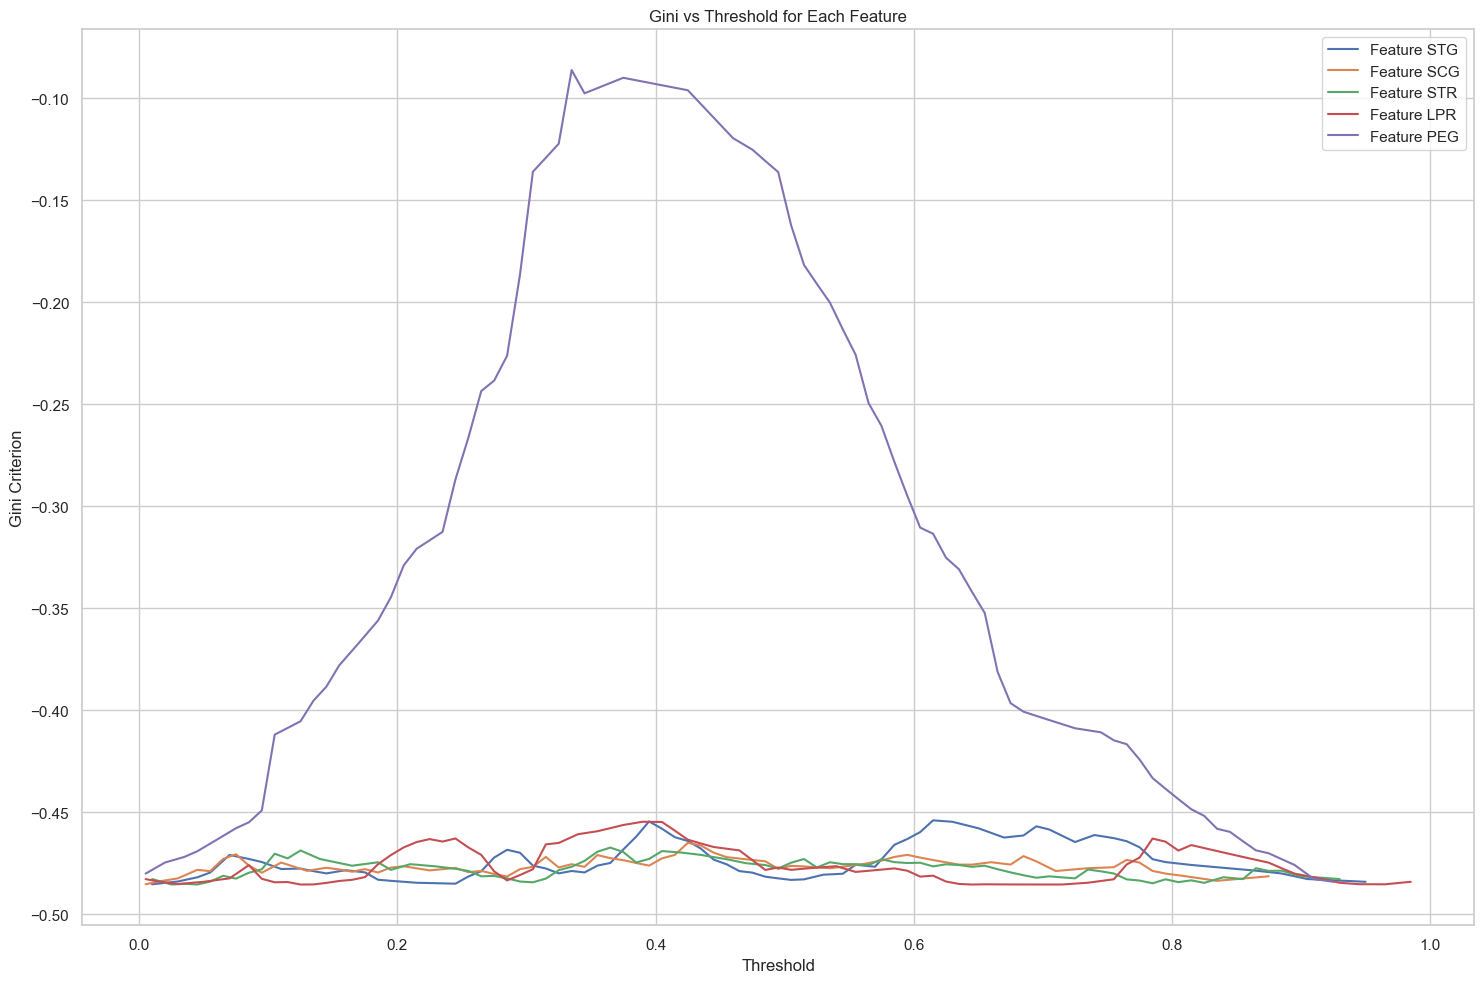

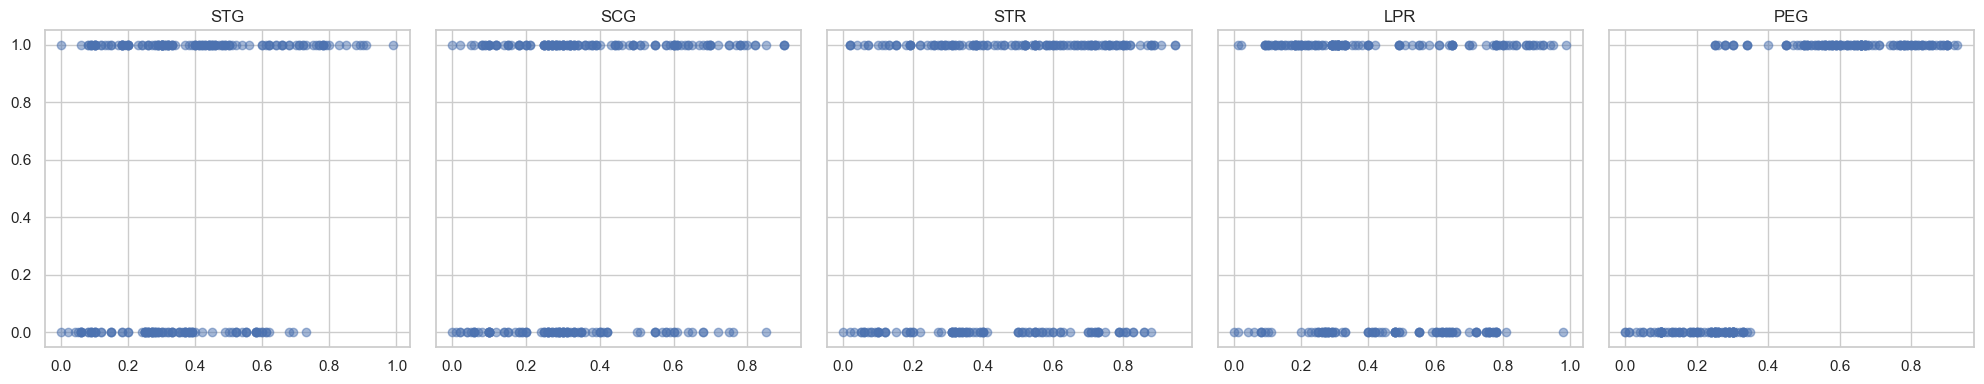

In [34]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from hw2code import find_best_split

df = pd.read_csv("datasets/students.csv")
X = df.iloc[:, :5]
y = df.iloc[:, -1]

plt.figure(figsize=(15, 10))
for col in X.columns:
    thresholds, ginis, _, _ = find_best_split(X[col], y)
    plt.plot(thresholds, ginis, label=f"Feature {col}")
plt.xlabel("Threshold")
plt.ylabel("Gini Criterion")
plt.title("Gini vs Threshold for Each Feature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, col in enumerate(X.columns):
    axes[i].scatter(X[col], y, alpha=0.5)
    axes[i].set_title(f"{col}")
    axes[i].grid(True)
plt.tight_layout()
plt.show()


__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:**

Исходя из значений - лучше разбивать по признаку PEG в значении примерно равным примерно 0.37 - если посмотреть на график кривых и на scatter-графиках. Признак PEG согласуется и с пятым "скейтером" - тоже примерно в значении 0.37 происходит резкий переход. В отличие от остальных графиков Scatter. Хорошие (-ий) признаки на графике напоминают график нормального распределения, чего не скажешь про остальные признаки - тащатся по дну.

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

ok

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [35]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from hw2code import DecisionTree
from sklearn.preprocessing import LabelEncoder

mushroom_data = pd.read_csv("datasets/agaricus-lepiota.data", header=None)
encoders = {}
for column in mushroom_data.columns:
    encoder = LabelEncoder()
    mushroom_data[column] = encoder.fit_transform(mushroom_data[column])
    encoders[column] = encoder
target = mushroom_data.iloc[:, 0].values
features = mushroom_data.iloc[:, 1:].values
feature_types = ["categorical"] * features.shape[1]
X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.5,
    stratify=target,
    random_state=42
)
mushroom_tree = DecisionTree(feature_types)
mushroom_tree.fit(X_train, y_train)
predictions = mushroom_tree.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy on mushrooms: {accuracy:.10f}")

def calculate_tree_depth(node):
    if node["type"] == "terminal":
        return 0
    left_depth = calculate_tree_depth(node["left_child"])
    right_depth = calculate_tree_depth(node["right_child"])
    return 1 + max(left_depth, right_depth)

tree_depth = calculate_tree_depth(mushroom_tree._tree)
print(f"Depth of the mushroom tree: {tree_depth}")

Accuracy on mushrooms: 1.0000000000
Depth of the mushroom tree: 7


ну и уловки же у вас в исходном коде... печально

__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

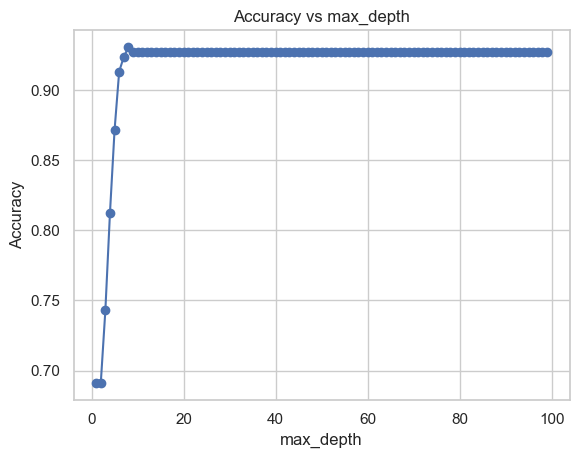

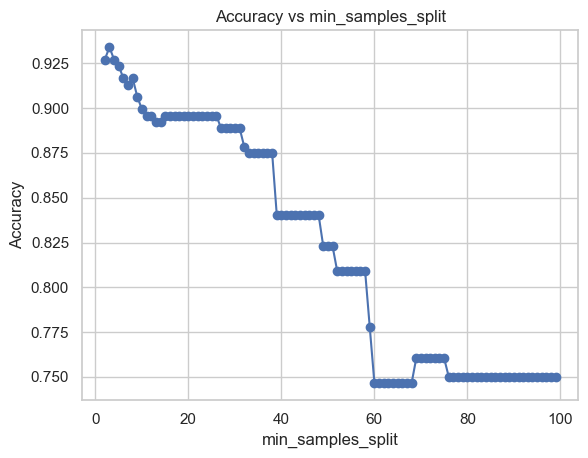

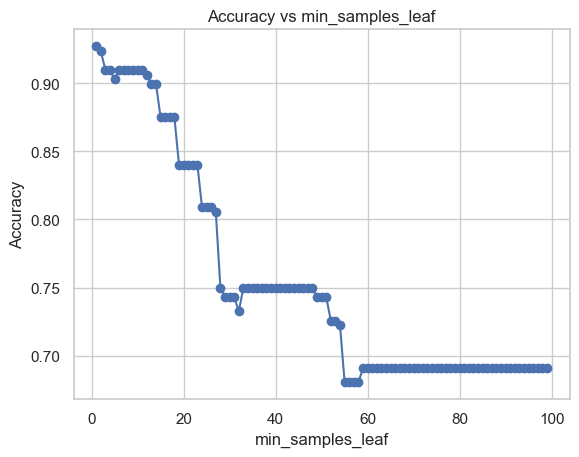

In [36]:
df = pd.read_csv('datasets/tic-tac-toe-endgame.csv')
X = df.drop('V10', axis=1).values
y = (df['V10'] == 'positive').astype(float).values
feature_types = ['categorical'] * X.shape[1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

max_depth_values = list(range(1, 100))
max_depth_scores = []
for depth in max_depth_values:
    clf = DecisionTree(feature_types, max_depth=depth)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    max_depth_scores.append(acc)

plt.figure()
plt.plot(max_depth_values, max_depth_scores, marker='o')
plt.title("Accuracy vs max_depth")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

min_samples_split_values = list(range(2, 100))
min_samples_split_scores = []
for samples in min_samples_split_values:
    clf = DecisionTree(feature_types, min_samples_split=samples)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    min_samples_split_scores.append(acc)
plt.figure()
plt.plot(min_samples_split_values, min_samples_split_scores, marker='o')
plt.title("Accuracy vs min_samples_split")
plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

min_samples_leaf_values = list(range(1, 100))
min_samples_leaf_scores = []
for samples in min_samples_leaf_values:
    clf = DecisionTree(feature_types, min_samples_leaf=samples)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    min_samples_leaf_scores.append(acc)

plt.figure()
plt.plot(min_samples_leaf_values, min_samples_leaf_scores, marker='o')
plt.title("Accuracy vs min_samples_leaf")
plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

Ожидаемо, если не дать дереву расти в высоту - эффект лучше - так как происходит рост в ширину и мы видим чудесный первый график

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [37]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold
datasets_new = {
    "mushrooms": "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data",
    "tic_tac_toe": "https://archive.ics.uci.edu/ml/machine-learning-databases/tic-tac-toe/tic-tac-toe.data",
    "cars": "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data",
    "nursery": "https://archive.ics.uci.edu/ml/machine-learning-databases/nursery/nursery.data"
}

results = []

for name, url in datasets_new.items():
    data = pd.read_csv(url, header=None)
    if name == "mushrooms":
        X = data.iloc[:, 1:]
        y = data.iloc[:, 0].map({'e': 1, 'p': 0})
    elif name == "tic_tac_toe":
        X = data.iloc[:, :-1]
        y = data.iloc[:, -1].map({'negative': 0, 'positive': 1})
    elif name == "cars":
        X = data.iloc[:, :-1]
        y = data.iloc[:, -1].map({'unacc': 0, 'acc': 0, 'good': 1, 'vgood': 1})
    elif name == "nursery":
        X = data.iloc[:, :-1]
        y = data.iloc[:, -1].map({'not_recom': 0, 'recommend': 0, 'very_recom': 1, 'priority': 1, 'spec_prior': 1})
    X_cat = X.values
    y = y.values
    X_num = np.zeros_like(X_cat, dtype=float)
    for col in range(X_cat.shape[1]):
        le = LabelEncoder()
        X_num[:, col] = le.fit_transform(X_cat[:, col])
    ohe = OneHotEncoder(sparse_output=False)
    X_ohe = ohe.fit_transform(X_cat)
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    acc_real = []
    acc_cat = []
    acc_ohe = []
    acc_sk = []
    for train_idx, test_idx in kf.split(X_cat):
        X_train_cat, X_test_cat = X_cat[train_idx], X_cat[test_idx]
        X_train_num, X_test_num = X_num[train_idx], X_num[test_idx]
        X_train_ohe, X_test_ohe = X_ohe[train_idx], X_ohe[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        tree_real = DecisionTree(feature_types=['real']*X_num.shape[1])
        tree_real.fit(X_train_num, y_train)
        pred = tree_real.predict(X_test_num)
        acc_real.append(accuracy_score(y_test, pred))

        tree_cat = DecisionTree(feature_types=['categorical']*X_cat.shape[1])
        tree_cat.fit(X_train_cat, y_train)
        pred = tree_cat.predict(X_test_cat)
        acc_cat.append(accuracy_score(y_test, pred))

        tree_ohe = DecisionTree(feature_types=['real']*X_ohe.shape[1])
        tree_ohe.fit(X_train_ohe, y_train)
        pred = tree_ohe.predict(X_test_ohe)
        acc_ohe.append(accuracy_score(y_test, pred))

        sk_tree = DecisionTreeClassifier()
        sk_tree.fit(X_train_ohe, y_train)
        pred = sk_tree.predict(X_test_ohe)
        acc_sk.append(accuracy_score(y_test, pred))

    results.append({
        'dataset': name,
        'my DT (numeric)': np.mean(acc_real),
        'my DT (cat)': np.mean(acc_cat),
        'my DT (one-hot cat)': np.mean(acc_ohe),
        'Sklearn DT': np.mean(acc_sk)
    })

results_df = pd.DataFrame(results).set_index('dataset')
print(results_df)

             my DT (numeric)  my DT (cat)  my DT (one-hot cat)  Sklearn DT
dataset                                                                   
mushrooms           1.000000     1.000000             1.000000    1.000000
tic_tac_toe         0.878914     0.942632             0.942632    0.947829
cars                0.990163     0.987273             0.987851    0.983792
nursery             0.999769     0.999769             0.999769    0.999769


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:**

судя по сводной таблице, для грибов и nursery все показывают примерно одинаковую точность (у грибов так вообще единица) - все потому что там признаки в основном категориальные и получается достаточно просто найти разделя.щие правила. Машинки в целом где-то рядом друг с другом, и даже близко к единице в одном из случаев. Но хуже всего отработал tic_tac_toe - видимо, там сложное взаимодействие признаков идет. Что касается случайности - то моё дерево вообще детерминировано, но всегда случайность можно добавить) Точночсть всегда можно попробовать поывсить за счет гиперпараметров или настройки признаков.

Вставьте что угодно, описывающее ваши впечатления от этого задания:

трудно. 5 утра. я спать